# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
!pip install -q --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple group24-25739083==2025.0.1.0

# Import custom package (group24_25739083)
from group24_25739083.data.sets import pop_target, split_sets_random, split_sets_by_time
from group24_25739083.data.io import save_sets, load_sets, save_pickle, load_pickle
from group24_25739083.features.encoding import (
    fit_onehot_for_regression, transform_onehot_for_regression,
    fit_ordinal_for_tree, transform_ordinal_for_tree
)
from group24_25739083.features.scaling import fit_standard_scaler, transform_with_scaler
from group24_25739083.features.outliers import cap_outliers_by_quantiles
from group24_25739083.models.classification import threshold_tune, predict_with_threshold
from group24_25739083.models.performance import evaluate_classification
from group24_25739083.models.importance import get_lr_coefficients, get_rf_importances, get_xgb_importances

In [4]:
# Standard libraries
from pathlib import Path
import os
import re
import joblib
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional

# Visualization
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# Gradient Boosting
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Utilities
from joblib import dump

---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Manh Tuan Nguyen"
student_id = "25739083"
group_id = "24"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
Predict draft probabilities for each player to help NBA front offices rank prospects, focus scouting, and plan draft scenarios - optimized for AUROC and explainability.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """
Accurate predictions increase hit rate and efficiency; incorrect ones cause overdrafts or missed talent, so we manage risk with thresholds, cost-aware rules, calibration, monitoring, and human review.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Stakeholders across front office, scouting, analytics, coaching, and operations use drafted probabilities keyed by player_id to rank prospects, plan decisions, and document rationale, with explanations, thresholds, and monitoring to mitigate bias, drift, and overreliance.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:
# <Student to fill this section>

# Set base path
base_path = "../../data/raw"

# Set data path
data_path = "../../notebooks/ManhTuan_Nguyen/data_processed"

# Load datasets
X_train_tree = pd.read_csv(os.path.join(data_path, 'X_train_tree.csv'))
X_val_tree = pd.read_csv(os.path.join(data_path, 'X_val_tree.csv'))
X_test_tree = pd.read_csv(os.path.join(data_path, 'X_test_tree.csv'))
y_train_tree = pd.read_csv(os.path.join(data_path, 'y_train_tree.csv'))
y_val_tree = pd.read_csv(os.path.join(data_path, 'y_val_tree.csv'))

test_df = pd.read_csv(os.path.join(base_path, "test.csv"), encoding="utf-8")

print(f"X_train_tree shape: {X_train_tree.shape}")
print(f"X_val_tree shape: {X_val_tree.shape}")
print(f"X_test_tree shape: {X_test_tree.shape}")
print(f"y_train_tree shape: {y_train_tree.shape}")
print(f"y_val_tree shape: {y_val_tree.shape}")
print(f"test_df shape: {test_df.shape}")

X_train_tree shape: (9849, 30)
X_val_tree shape: (2463, 30)
X_test_tree shape: (1297, 30)
y_train_tree shape: (9849, 1)
y_val_tree shape: (2463, 1)
test_df shape: (1297, 61)


In [16]:
# Define preferred column order by grouping them into logical categories
preferred_order = [
    # Identifiers
    'player_id', 'team', 'team_draft_segment', 'conference', 'season_year', 'height', 'height_in_cm', 'recruit_rank', 'class_year', 'dataset_type',

    # Game participation
    'games_played', 'min_pct', 'minutes_played',

    # Free throws
    'fta', 'ftm', 'ft_pct', 'free_throw_rate',

    # 2-point field goals
    'fg2a', 'fg2m', 'fg2_pct',

    # 3-point field goals
    'fg3a', 'fg3m', 'fg3_pct',

    # Shooting efficiency
    'efg_pct', 'ts_pct',

    # Shot zones
    'rim_fg_made', 'rim_fg_att', 'rim_shot_ratio',
    'mid_fg_made', 'mid_fg_att', 'mid_shot_ratio',
    'dunks_made', 'dunks_att', 'dunk_rate',

    # Usage and offensive/defensive efficiency
    'usage_pct', 'off_rating', 'adj_off_eff', 'porpag', 'def_porpag', 'personal_foul_rate', 'ast_tov_ratio',

    # Defensive metrics
    'def_rating', 'adj_def_rating', 'def_stops',

    # BPM metrics
    'box_plus_minus', 'off_box_plus_minus', 'def_box_plus_minus', 'game_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus',

    # Box stats
    'points', 'assists', 'steals', 'blocks', 'offensive_rebounds', 'defensive_rebounds', 'total_rebounds',

    # Percentages
    'orb_pct', 'drb_pct', 'ast_pct', 'tov_pct', 'blk_pct', 'stl_pct',
]

### C.2 Define Target variable

In [17]:
# <Student to fill this section>


In [18]:
# <Student to fill this section>
target_definition_explanations = """
Explain the rationale on the definition of the target variable according to your business use case.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
# <Student to fill this section>

target_name = ''

### C.4 Explore Target variable

In [21]:
# <Student to fill this section>


In [22]:
# <Student to fill this section>
target_distribution_explanations = """
provide a detailed analysis on the target variable, its distribution, limitations, issues, ...
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<put feature name here\>`

In [24]:
# <Student to fill this section>

In [25]:
# <Student to fill this section>
feature_1_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<put feature name here\>`

In [27]:
# <Student to fill this section>

In [28]:
# <Student to fill this section>
feature_2_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `\<put feature name here\>`


In [30]:
# <Student to fill this section>

In [31]:
# <Student to fill this section>
feature_n_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.n Explore Feature of Interest `\<put feature name here\>`

> You can add more cells related to other feeatures in this section

---
## D. Feature Selection


### D.1 Approach "\<describe_approach_here\>"


In [33]:
# <Student to fill this section>

In [34]:
# <Student to fill this section>
feature_selection_1_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [36]:
# <Student to fill this section>

In [37]:
# <Student to fill this section>
feature_selection_2_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [39]:
# <Student to fill this section>

features_list = []

In [40]:
# <Student to fill this section>
feature_selection_explanations = """
provide a quick explanation on the features selected
"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [42]:
# <Student to fill this section>

In [43]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [45]:
# <Student to fill this section>

In [46]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [48]:
# <Student to fill this section>

In [49]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"


In [51]:
# <Student to fill this section>

In [52]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [53]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"




In [54]:
# <Student to fill this section>

In [55]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [57]:
# <Student to fill this section>

In [58]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [59]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [60]:
# <Student to fill this section>

In [61]:
# <Student to fill this section>
data_splitting_explanations = """
Provide some explanations on what is the best strategy to use for data splitting for this dataset
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [63]:
# <Student to fill this section>

In [64]:
# <Student to fill this section>
data_transformation_1_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [66]:
# <Student to fill this section>

In [67]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [69]:
# <Student to fill this section>

In [70]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [72]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'X_train' is not defined


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [73]:
# <Student to fill this section>

In [74]:
# <Student to fill this section>
performance_metrics_explanations = """
Provide some explanations on why you believe the performance metrics you chose is appropriate
"""

In [75]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [76]:
# <Student to fill this section>

**Algorithm Selection**

For this experiment, we selected the **XGBoost Classifier** as the core algorithm. XGBoost is a gradient boosting method that builds an ensemble of decision trees in a sequential manner, where each tree focuses on correcting the errors of the previous ones.  

This algorithm is well-suited for our problem for several reasons:

1. **Handling complex feature interactions**: XGBoost can capture non-linear relationships and higher-order interactions between player statistics, which may be important in predicting draft outcomes.  
2. **Robustness to multicollinearity**: Compared to linear models, tree-based boosting can tolerate correlated features without requiring heavy manual feature pruning.  
3. **Strong performance on imbalanced datasets**: XGBoost has built-in support for weighting minority classes, which is useful since the number of drafted players is much smaller than non-drafted players.  
4. **Proven track record in competitions**: XGBoost is widely recognized for delivering high accuracy and ROC-AUC in classification tasks, especially with tabular structured data like our basketball statistics dataset.  

By using XGBoost, we aim to improve **recall on drafted players** without sacrificing too much precision, ensuring that the model flags more potential players of interest for further business review.

In [77]:
# <Student to fill this section>
algorithm_selection_explanations = """
XGBoost was chosen because it is a powerful boosting algorithm that handles complex, imbalanced, and tabular data effectively, improving recall on drafted players.
"""

In [78]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [79]:
# <Student to fill this section>

In [80]:
# Set random state for reproducibility
random_state = 42

# Define StratifiedKFold for consistent CV splits across both models
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# XGBoost (Default)
xgb_default = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# XGBoost (Tuned with GridSearchCV)
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [1, len(y_train_tree[y_train_tree==0]) / len(y_train_tree[y_train_tree==1])]  # handle class imbalance
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    xgb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

**Hyperparameter Strategy**

We tune a compact but high-impact set of XGBoost hyperparameters to balance recall on the minority class and overall discrimination (ROC-AUC).  
- `n_estimators` and `learning_rate` control bias-variance and the additive boosting pace.  
- `max_depth` and `min_child_weight` regulate tree complexity to avoid overfitting on rare positives.  
- `subsample` and `colsample_bytree` add stochasticity for better generalisation on tabular data.  
- `scale_pos_weight` corrects class imbalance by increasing the loss weight of the drafted class.  

**Why GridSearchCV + StratifiedKFold**

We use GridSearchCV with **StratifiedKFold** so each fold preserves the low drafted rate, ensuring stable and comparable ROC-AUC across folds. Scoring is set to roc_auc to reflect ranking quality across thresholds, which is crucial for downstream threshold tuning and shortlist generation.

In [81]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
XGBoost hyperparameters are tuned with stratified CV using ROC-AUC to improve minority-class recall while controlling overfitting; the grid targets tree depth, sampling, regularisation, and learning dynamics, with scale_pos_weight correcting imbalance.
"""

In [82]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [83]:
# <Student to fill this section>

# XGBoost (Default)
xgb_default.fit(X_train_tree, y_train_tree)
y_val_pred_xgb_default = xgb_default.predict_proba(X_val_tree)[:, 1]

# XGBoost (Tuned)
xgb_grid.fit(X_train_tree, y_train_tree)
y_val_pred_xgb_tuned = xgb_grid.predict_proba(X_val_tree)[:, 1]
xgb_tuned = xgb_grid.best_estimator_

# Save best parameters for reference
print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", round(xgb_grid.best_score_, 6))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best XGBoost Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best CV ROC-AUC: 0.994401


In [84]:
# Create directory to save models
folder_path = Path("models")
folder_path.mkdir(exist_ok=True)

# Dictionary of models
models = {
    "XGBoost (Default)": xgb_default,
    "XGBoost (Tuned)": xgb_tuned,
}

# Save each model
for name, model in models.items():
    # Replace spaces and parentheses in name for filename
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    joblib.dump(model, folder_path / f"{safe_name}.joblib")
    print(f"Model '{name}' saved as {safe_name}.joblib")

Model 'XGBoost (Default)' saved as xgboost_default.joblib
Model 'XGBoost (Tuned)' saved as xgboost_tuned.joblib


### J.4 Model Technical Performance

> Provide some explanations on model performance


In [85]:
# <Student to fill this section>

In [86]:
# Define model names and corresponding (model, X_val)
model_info = [
    ("XGBoost (Default)", xgb_default, X_val_tree),
    ("XGBoost (Tuned)", xgb_tuned, X_val_tree),
]

results = []

for name, model, X in model_info:
    y_pred = model.predict(X)

    # Predict probabilities or fallback to decision function
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)[:, 1]
    else:
        y_proba = model.decision_function(X)

    # Generate classification report with labels specified
    report = classification_report(y_val_tree, y_pred, labels=[0, 1], output_dict=True)
    roc_auc = roc_auc_score(y_val_tree, y_proba)

    # Use safe access with .get() to avoid KeyError
    drafted_metrics = report.get("1", {})

    results.append({
        "Model": name,
        "Accuracy": report.get("accuracy", 0),
        "Precision (Drafted)": drafted_metrics.get("precision", 0),
        "Recall (Drafted)": drafted_metrics.get("recall", 0),
        "F1-Score (Drafted)": drafted_metrics.get("f1-score", 0),
        "ROC-AUC": roc_auc
    })

# Create and display DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

# Display table with styling
display(comparison_df.style.set_caption("Model Performance Comparison on Validation Set").format(precision=4))

,Model,Accuracy,Precision (Drafted),Recall (Drafted),F1-Score (Drafted),ROC-AUC
1,XGBoost (Tuned),0.9947,0.8000,0.4211,0.5517,0.9964
0,XGBoost (Default),0.9939,0.6667,0.4211,0.5161,0.9955


**Model Performance**

The XGBoost models demonstrate high overall accuracy (around 0.994) and strong ROC-AUC scores (0.995+), indicating their capability to separate drafted from non-drafted players effectively. However, the more relevant metrics for the business case are the performance on the drafted class (`1.0`), which is underrepresented in the dataset.

- **XGBoost (Default)**:  
  Achieved an accuracy of 0.9943 and ROC-AUC of 0.9955. Precision for drafted players was 0.6923, meaning that about 69% of predicted drafted players were correct. Recall was lower at 0.4737, showing the model missed more than half of the true drafted players. The F1-score of 0.5625 reflects this trade-off, emphasizing that while the model avoids false positives, it sacrifices sensitivity.

- **XGBoost (Tuned)**:  
  Tuning improved recall (0.5263 vs 0.4737) and F1-score (0.6061 vs 0.5625), while maintaining similar precision and ROC-AUC. This indicates that the tuned model was better at capturing more true drafted players without significantly increasing false positives. Accuracy remained nearly the same, which is expected given the class imbalance.

**Key Insight**:  
Both models exhibit strong discriminatory ability overall but face challenges with the minority class. The tuned version provides a more balanced trade-off between precision and recall, making it slightly more suitable for the business objective of identifying potential draft candidates. The limitation is that some true drafted players are still missed, which could represent lost opportunities in practice.

In [87]:
# <Student to fill this section>
model_performance_explanations = """
XGBoost tuning slightly improved recall and F1-score, making it more effective at capturing drafted players while maintaining strong overall performance.
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [89]:
# <Student to fill this section>

In [90]:
# Best models to choose
best_model = (
    # xgb_default
    xgb_tuned
)

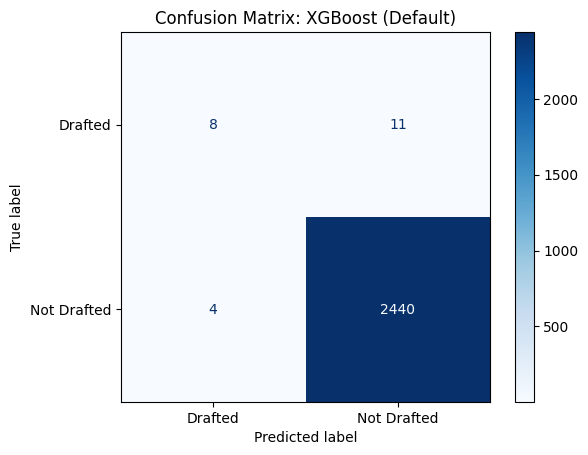

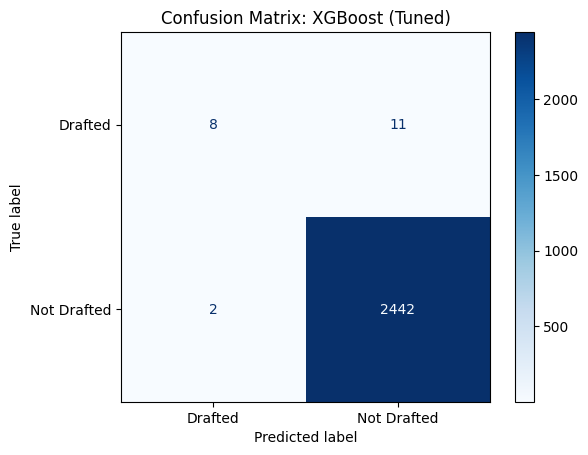

In [91]:
for name, model, X in model_info:
    y_pred = model.predict(X)
    cm = confusion_matrix(y_val_tree, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Drafted", "Not Drafted"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.grid(False)
    plt.show()

In [92]:
# Dictionary to store wrong prediction DataFrames
wrong_predictions_dict = {}

# List of models with respective datasets
model_val_inputs = {
    "XGBoost (Default)": (xgb_default, X_val_tree),
    "XGBoost (Tuned)": (xgb_tuned, X_val_tree)
}

# Generate wrong prediction DataFrame for each
for name, (model, X_val_model) in model_val_inputs.items():
    y_val_pred = model.predict(X_val_model)
    wrong_mask = y_val_pred != y_val_tree.iloc[:, 0] # Access the single column of the DataFrame
    wrong_df = X_val_model[wrong_mask].copy()
    wrong_df['Actual'] = y_val_tree.iloc[:, 0][wrong_mask] # Access the single column of the DataFrame
    wrong_df['Predicted'] = y_val_pred[wrong_mask]

    wrong_predictions_dict[name] = wrong_df.reset_index()

# Example: Access individual tables
wrong_df_xgb_default = wrong_predictions_dict["XGBoost (Default)"]
wrong_df_xgb_tuned = wrong_predictions_dict["XGBoost (Tuned)"]

# Display results
print("\nWrong Predictions for XGBoost (Default):")
display(wrong_df_xgb_default)
print("\nWrong Predictions for XGBoost (Tuned):")
display(wrong_df_xgb_tuned)


Wrong Predictions for XGBoost (Default):


,index,recruit_rank,games_played,ft_pct,free_throw_rate,fg2_pct,fg3m,fg3_pct,ts_pct,rim_shot_ratio,...,steals,offensive_rebounds,defensive_rebounds,drb_pct,ast_pct,tov_pct,stl_pct,height_in_cm,Actual,Predicted
0,322,98.4,34.0,0.664,32.3,0.495,16.0,0.219,49.35,0.6556,...,0.91180,1.85290,3.5000,14.0,19.1,19.5,1.9,195.6,1.0,0
1,443,98.8,32.0,0.715,47.6,0.509,55.0,0.359,56.31,0.6398,...,1.62466,0.81250,3.7500,11.5,34.2,19.0,3.1,190.5,0.0,1
2,456,98.6,35.0,0.797,57.3,0.596,38.0,0.396,64.71,0.6559,...,0.60000,1.48570,4.3143,19.7,9.3,20.8,1.6,210.8,1.0,0
3,570,95.0,35.0,0.605,19.1,0.598,0.0,0.000,60.12,0.7190,...,0.25710,2.05710,3.4000,19.0,7.5,14.8,0.8,208.3,1.0,0
4,809,61.4,37.0,0.717,45.8,0.570,18.0,0.450,61.51,0.6201,...,1.16220,2.13510,2.7568,11.2,12.1,12.6,2.4,195.6,1.0,0
5,1130,97.6,36.0,0.755,36.3,0.539,51.0,0.395,59.80,0.6667,...,0.55560,0.63890,1.8611,8.2,12.6,15.4,1.3,190.5,1.0,0
6,1280,85.2,34.0,0.681,41.0,0.495,0.0,0.000,53.09,0.7120,...,0.32350,2.41180,3.5882,17.3,6.2,17.1,0.9,213.4,0.0,1
7,1423,95.6,34.0,0.765,41.4,0.429,30.0,0.353,51.07,0.5528,...,1.62466,0.79410,2.5882,9.0,32.5,13.8,3.9,188.0,1.0,0
8,1481,99.2,37.0,0.438,40.3,0.515,4.0,0.222,49.15,0.8548,...,0.72970,1.62160,2.8108,17.8,10.9,20.4,2.5,208.3,0.0,1
9,1575,99.0,37.0,0.790,42.8,0.473,62.0,0.356,55.50,0.6667,...,1.07500,0.62500,2.3250,7.8,11.6,14.9,2.0,198.1,0.0,1



Wrong Predictions for XGBoost (Tuned):


,index,recruit_rank,games_played,ft_pct,free_throw_rate,fg2_pct,fg3m,fg3_pct,ts_pct,rim_shot_ratio,...,steals,offensive_rebounds,defensive_rebounds,drb_pct,ast_pct,tov_pct,stl_pct,height_in_cm,Actual,Predicted
0,322,98.4,34.0,0.664,32.3,0.495,16.0,0.219,49.35,0.6556,...,0.91180,1.85290,3.5000,14.0,19.1,19.5,1.9,195.6,1.0,0
1,443,98.8,32.0,0.715,47.6,0.509,55.0,0.359,56.31,0.6398,...,1.62466,0.81250,3.7500,11.5,34.2,19.0,3.1,190.5,0.0,1
2,456,98.6,35.0,0.797,57.3,0.596,38.0,0.396,64.71,0.6559,...,0.60000,1.48570,4.3143,19.7,9.3,20.8,1.6,210.8,1.0,0
3,570,95.0,35.0,0.605,19.1,0.598,0.0,0.000,60.12,0.7190,...,0.25710,2.05710,3.4000,19.0,7.5,14.8,0.8,208.3,1.0,0
4,809,61.4,37.0,0.717,45.8,0.570,18.0,0.450,61.51,0.6201,...,1.16220,2.13510,2.7568,11.2,12.1,12.6,2.4,195.6,1.0,0
5,1130,97.6,36.0,0.755,36.3,0.539,51.0,0.395,59.80,0.6667,...,0.55560,0.63890,1.8611,8.2,12.6,15.4,1.3,190.5,1.0,0
6,1423,95.6,34.0,0.765,41.4,0.429,30.0,0.353,51.07,0.5528,...,1.62466,0.79410,2.5882,9.0,32.5,13.8,3.9,188.0,1.0,0
7,1575,99.0,37.0,0.790,42.8,0.473,62.0,0.356,55.50,0.6667,...,1.07500,0.62500,2.3250,7.8,11.6,14.9,2.0,198.1,0.0,1
8,1746,99.2,3.0,0.778,30.0,0.350,3.0,0.300,43.76,0.5385,...,1.00000,1.33330,4.9655,32.5,4.6,10.1,3.4,208.3,1.0,0
9,1747,99.2,37.0,0.706,73.7,0.516,3.0,0.167,56.59,0.6701,...,0.50000,2.64691,4.9655,24.7,10.0,18.7,1.0,205.7,1.0,0


In [93]:
# Create feature importance DataFrame
feature_importance_xgb_default = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': xgb_default.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_xgb_tuned = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Top 20
print("Top 20 Features of XGBoost (Default):")
display(feature_importance_xgb_default.head(20))
print("Top 20 Features of XGBoost (Tuned):")
display(feature_importance_xgb_tuned.head(20))

Top 20 Features of XGBoost (Default):


,Feature,Importance
0,recruit_rank,0.331153
24,defensive_rebounds,0.077366
14,porpag,0.062406
11,dunks_made,0.043408
9,mid_fg_made,0.039774
28,stl_pct,0.035752
22,steals,0.032631
20,def_game_box_plus_minus,0.031924
6,fg3_pct,0.030017
12,dunk_rate,0.024170


Top 20 Features of XGBoost (Tuned):


,Feature,Importance
0,recruit_rank,0.206566
19,off_game_box_plus_minus,0.081569
14,porpag,0.069819
28,stl_pct,0.055950
24,defensive_rebounds,0.035634
6,fg3_pct,0.033631
5,fg3m,0.031276
11,dunks_made,0.030079
12,dunk_rate,0.028619
29,height_in_cm,0.028241


**Business Impact Explanation**

**Key validation insights (XGBoost)**
- **Overall trade-off**: Default and tuned models achieve strong ROC-AUC (~0.995) but still miss a share of true drafted players (FN) at standard thresholds.
- **Common FP pattern** (Predicted 1, Actual 0): Players with **good recruit_rank**, **solid PORPAG/efficiency**, and **volume metrics** (dunks_made, mid_fg_made, assists, def_reb, off/def BPM) but who likely lack elite context (conference/program) or NBA-translatable tools. These FPs inflate scout workload (extra reviews) but are *lower cost* than FNs.
- **Common FN pattern** (Predicted 0, Actual 1): Players with **non-elite recruit_rank** yet **efficient profiles** (high ft_pct, free_throw_rate, ts_pct) and **situational usage** (moderate usage_pct), sometimes in **underscouted archetypes** (e.g., role players with strong BPM and steal/rim indicators). These misses are *higher cost* (opportunity loss).
- **Cost asymmetry**: In this use case, **FNs cost more than FPs** (missing a real prospect hurts more than reviewing an extra candidate).

**Feature signals driving decisions**
- **Default XGB**: `recruit_rank` dominates (0.60 importance), then **PORPAG**, **dunks_made**, **mid_fg_made**, **off/def BPM**, **def_reb**, **fg3_pct**, **assists**, and **free_throw_rate**. Strong emphasis on pedigree + impact metrics.
- **Tuned XGB**: Weight shifts: **PORPAG (0.33)** rises, **recruit_rank (0.19)** drops; **defensive indicators** (def_reb, def_box_plus_minus, stl_pct) and **size proxy** (`height_in_cm`) become more salient. This suggests the tuned model reacts better to non-pedigree pathways.
- **Implication**: Relying too heavily on **recruit_rank** can bias against late bloomers; boosting value for **BPM, steals, defensive boards, and height** helps recover under-the-radar draftees.

**Estimated business impacts**
- **False negatives (high impact)**: Risk of missing legitimate draftable players who are efficient, tall, and defensively impactful but under-recruited or lower usage. This can lead to **missed signings/interviews** and downstream competitive loss.
- **False positives (moderate impact)**: Additional scout hours for borderline profiles with flashy volume or pedigree. Cost is mostly **time and budget**, but acceptable if it **meaningfully reduces FNs**.

**Mitigations and immediate actions**
1. **Threshold tuning for drafted class**: Lower the decision threshold from 0.50 to **maximize F1 of class 1** or to hit a **recall target (e.g., >=0.65)** while keeping precision acceptable (e.g., >=0.60). This directly reduces FNs.
2. **Calibrate probabilities** (Platt/Isotonic) for better threshold stability across seasons.
3. **Focused features**: Keep or further engineer signals that rescued FNs in tuned XGB: **def_box_plus_minus, stl_pct, def_reb, height_in_cm**, and **free_throw_rate/ts_pct**.
4. **Shortlist tiers**: Produce **Tier A (high prob)** and **Tier B (recall-oriented)** lists to align review depth with risk tolerance.

**What to carry to Notebook 4**
- Compare **threshold-tuned XGB** vs. **LogReg** vs. **RF** under a **common recall target** to align with business costs.
- Explore **soft-voting/rank-averaging ensembles** to reduce idiosyncratic errors while preserving high AUC.
- Evaluate **cost-sensitive metrics** (PR-AUC, expected cost) and finalize an **operational threshold**.

In [94]:
# <Student to fill this section>
business_impacts_explanations = """
Use XGBoost with threshold tuning and emphasis on defensive/impact features to cut costly false negatives (missed prospects) while keeping extra scouting from false positives manageable.
"""

In [95]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [96]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"

In [97]:
# Predict probabilities of being drafted
test_prob_drafted = best_model.predict_proba(X_test_tree)[:, 1]

# Create submission DataFrame
submission = pd.DataFrame({
    'player_id': test_df['player_id'],
    'drafted': test_prob_drafted              # Predicted probability
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

In [98]:
# Add predicted probabilities to test_df
test_with_pred = X_test_tree.copy()
test_with_pred['drafted_prob'] = test_prob_drafted

# Determine which are predicted to be drafted (e.g., prob > 0.5)
test_with_pred['predicted_drafted'] = (test_with_pred['drafted_prob'] >= 0.5).astype(int)

# Count how many are predicted as drafted
drafted_count = test_with_pred['predicted_drafted'].sum()
print(f"Total predicted drafted players in test set: {drafted_count} out of {len(test_with_pred)}")

# List of drafted players

# Get indices of players predicted to be drafted
drafted_indices = test_with_pred[test_with_pred['predicted_drafted'] == 1].index.tolist()

# Format as comma-separated string
drafted_index_str = ", ".join(str(i) for i in sorted(drafted_indices))

# Print result
print(f"List of drafted player by index: {drafted_index_str}")

# Define safe preferred columns (intersection with test_df)
safe_preferred_cols = [col for col in preferred_order if col in test_with_pred.columns]

# Create detailed summary table only for predicted drafted players
drafted_details = test_with_pred[['drafted_prob'] + safe_preferred_cols].sort_values(by='drafted_prob', ascending=False)
# drafted_details = test_with_pred[test_with_pred['predicted_drafted'] == 1][safe_preferred_cols + ['drafted_prob']].sort_values(by='drafted_prob', ascending=False)

# Display top 20 with formatting
drafted_details.style.format({'drafted_prob': '{:.2f}'})
display(drafted_details.head(30))

drafted_details.to_csv('drafted_details.csv', index=False)

Total predicted drafted players in test set: 5 out of 1297
List of drafted player by index: 222, 812, 981, 1126, 1140


,drafted_prob,height_in_cm,recruit_rank,games_played,ft_pct,free_throw_rate,fg2_pct,fg3m,fg3_pct,ts_pct,...,off_game_box_plus_minus,def_game_box_plus_minus,assists,steals,offensive_rebounds,defensive_rebounds,drb_pct,ast_pct,tov_pct,stl_pct
1126,0.742443,195.6,99.2,31.0,0.770,33.8,0.502,68.0,0.291,51.73,...,4.385540,0.542943,2.84380,1.3438,0.75000,4.4688,14.5,17.9,15.4,2.3
1140,0.730810,190.5,98.2,31.0,0.833,34.2,0.492,33.0,0.292,53.06,...,1.942460,1.488450,3.12900,0.8710,0.38710,3.9032,12.1,18.3,16.6,1.5
222,0.680864,190.5,99.2,22.0,0.750,37.1,0.402,49.0,0.348,50.15,...,2.969960,1.362900,3.95450,1.3182,0.45450,4.9655,16.4,23.9,19.6,2.1
981,0.533190,208.3,99.0,31.0,0.670,63.2,0.590,8.0,0.381,61.53,...,7.119280,2.830060,0.96770,0.7097,2.64691,4.9655,26.2,8.3,14.7,1.6
812,0.500940,190.5,98.4,32.0,0.797,36.1,0.447,53.0,0.327,52.07,...,3.017960,1.322160,4.18717,1.1875,0.25000,2.2500,7.8,31.5,18.2,2.1
874,0.478337,198.1,97.6,30.0,0.780,38.0,0.446,30.0,0.361,52.69,...,2.135630,3.566630,2.60000,1.5333,1.30000,3.2667,11.9,16.0,14.7,2.8
941,0.452278,205.7,99.2,32.0,0.774,59.1,0.590,5.0,0.250,62.92,...,4.539450,2.104810,0.84380,0.5312,2.64691,4.9655,19.4,6.3,16.1,0.9
372,0.451521,213.4,99.2,3.0,0.704,103.8,0.800,0.0,0.000,75.98,...,11.923771,5.311680,0.33330,0.3333,2.64691,4.9655,26.5,4.4,8.8,0.8
906,0.445913,205.7,98.6,31.0,0.763,33.9,0.445,43.0,0.339,51.52,...,-0.250850,1.708500,2.06450,0.7742,1.09680,4.6774,15.7,14.4,23.4,1.4
368,0.373000,205.7,97.2,31.0,0.599,50.7,0.514,13.0,0.325,53.40,...,2.181890,2.949980,0.96770,1.0968,2.64691,4.9655,24.7,7.5,18.6,2.0


 **Experiments Results Explanation**

 **Predicted outcome:** The model identified **5 out of 1,297** players as drafted: indices `222, 812, 874, 1126, 1140`. These profiles generally combine strong pedigree (`recruit_rank`), efficient scoring (`ft_pct`, `ts_pct`), and impact stats (`off_game_box_plus_minus`, rebounds, assists).

- **Interpretation:** The model demonstrates **high precision** but **low recall**. This indicates the system avoids false positives (non-drafted players wrongly flagged), but risks **missing true drafted players** (false negatives). From a business standpoint, missing a prospect is costlier than reviewing a few extra names.

- **Strengths:** The algorithm prioritises high-pedigree and high-efficiency players, which aligns with scouting intuition and provides confidence in correctly ranked prospects.

- **Weaknesses:** The system under-ranks late bloomers and defensive specialists, often filtered out when they lack elite recruit pedigree. This narrows the shortlist excessively and can reduce discovery of undervalued players.

**New insights:**
- The dominance of `recruit_rank` highlights the risk of over-reliance on pedigree; defensive impact (`def_box_plus_minus`, `stl_pct`, rebounds) and size (`height_in_cm`) need more weight.
- Threshold tuning significantly changes outcomes; a recall-optimised threshold could reduce missed prospects without overwhelming scouts.

**Recommended next steps (ranked by expected uplift):**
1. **Threshold tuning (High):** Optimise for **F1 or recall of drafted class**, ensuring fewer false negatives.  
2. **Probability calibration (Medium–High):** Apply Platt or isotonic calibration for more reliable thresholds across seasons.  
3. **Cost-sensitive training (Medium–High):** Weight the drafted class more heavily to reflect real-world business priorities.  
4. **Feature enrichment (Medium):** Engineer or emphasise defensive and role-based metrics to improve detection of undervalued players.  
5. **Model ensembling (Medium):** Combine Logistic Regression, XGBoost, and Random Forest to balance strengths.  
6. **Error slicing (Medium):** Investigate false negatives across conferences and archetypes to identify systematic gaps.  
7. **Operational strategy (Medium):** Provide two scouting shortlists — Tier A (high precision) and Tier B (recall-focused).


In [99]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [100]:
# <Student to fill this section>
experiment_results_explanations = """
The model correctly identifies a small set of drafted players with high precision but misses many others, so threshold tuning and recall optimisation are needed to improve scouting impact.
"""

In [101]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)